In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Environment setup
# ═══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

ROOT  = '/content/drive/MyDrive/NSII_Research'
ONET  = f'{ROOT}/onet'
BLS   = f'{ROOT}/bls'
IPUMS = f'{ROOT}/IPUMS'
HMDA  = f'{ROOT}/hmda'
FRED  = f'{ROOT}/fred'
AUTO  = f'{ROOT}'

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
})

print("Environment ready.")
print(f"Root: {ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready.
Root: /content/drive/MyDrive/NSII_Research


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Load O*NET core tables
# ═══════════════════════════════════════════════════════════════
skills   = pd.read_excel(f'{ONET}/Skills.xlsx')
work_act = pd.read_excel(f'{ONET}/Work Activities.xlsx')
occ_data = pd.read_excel(f'{ONET}/Occupation Data.xlsx')
tasks    = pd.read_excel(f'{ONET}/Task Ratings.xlsx')

print("O*NET Tables Loaded")
print("=" * 50)
print(f"Skills:          {len(skills):>8,} rows  |  {skills.shape[1]} cols")
print(f"Work Activities: {len(work_act):>8,} rows  |  {work_act.shape[1]} cols")
print(f"Occupations:     {len(occ_data):>8,} rows  |  {occ_data.shape[1]} cols")
print(f"Task Ratings:    {len(tasks):>8,} rows  |  {tasks.shape[1]} cols")

# Integrity checks
assert len(skills)   > 60000, f"Skills rows unexpectedly low: {len(skills)}"
assert len(work_act) > 70000, f"Work Activities rows unexpectedly low: {len(work_act)}"
assert len(occ_data) > 1000,  f"Occupations rows unexpectedly low: {len(occ_data)}"
assert len(tasks)    > 150000,f"Task Ratings rows unexpectedly low: {len(tasks)}"

assert 'O*NET-SOC Code' in skills.columns,   "Missing O*NET-SOC Code in skills"
assert 'Scale Name' in skills.columns,        "Missing Scale Name in skills"
assert 'Data Value' in skills.columns,        "Missing Data Value in skills"
assert 'O*NET-SOC Code' in work_act.columns, "Missing O*NET-SOC Code in work_act"
assert 'O*NET-SOC Code' in occ_data.columns, "Missing O*NET-SOC Code in occ_data"

print("\nAll integrity checks passed. ✔")
print("\nSkills columns:")
print(list(skills.columns))
print("\nSample occupations:")
print(occ_data[['O*NET-SOC Code','Title']].head(10).to_string(index=False))

O*NET Tables Loaded
Skills:            62,580 rows  |  15 cols
Work Activities:   73,308 rows  |  15 cols
Occupations:        1,016 rows  |  3 cols
Task Ratings:     161,559 rows  |  15 cols

All integrity checks passed. ✔

Skills columns:
['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevant', 'Date', 'Domain Source']

Sample occupations:
O*NET-SOC Code                               Title
    11-1011.00                    Chief Executives
    11-1011.03       Chief Sustainability Officers
    11-1021.00     General and Operations Managers
    11-1031.00                         Legislators
    11-2011.00 Advertising and Promotions Managers
    11-2021.00                  Marketing Managers
    11-2022.00                      Sales Managers
    11-2032.00           Public Relations Managers
    11-2033.00                Fundraising Managers
    11-30

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — 31 target occupations
# ═══════════════════════════════════════════════════════════════

TARGET_SOC = [
    '43-3031.00','43-9061.00','43-4051.00','43-1011.00','23-2011.00',
    '41-2031.00','51-9061.00','53-7051.00','43-5061.00','13-2011.00',
    '51-4041.00','51-4121.00','51-2041.00','49-9041.00','17-2141.00',
    '17-2112.00','11-3051.00','51-1011.00','51-4081.00','17-3026.00',
    '15-1252.00','15-1211.00','15-1244.00','15-1231.00','13-1161.00',
    '11-2021.00','29-2011.00','17-2061.00','15-2031.00','11-9041.00',
    '15-2051.00',
]

TARGET_NAMES = {
    '43-3031.00': 'Bookkeeping Clerks',
    '43-9061.00': 'Office Clerks',
    '43-4051.00': 'Customer Service Reps',
    '43-1011.00': 'Office Supervisors',
    '23-2011.00': 'Paralegals',
    '41-2031.00': 'Retail Salespersons',
    '51-9061.00': 'Inspectors/Testers',
    '53-7051.00': 'Industrial Truck Operators',
    '43-5061.00': 'Production Planners',
    '13-2011.00': 'Accountants',
    '51-4041.00': 'Machinists',
    '51-4121.00': 'Welders',
    '51-2041.00': 'Metal Fabricators',
    '49-9041.00': 'Machinery Mechanics',
    '17-2141.00': 'Mechanical Engineers',
    '17-2112.00': 'Industrial Engineers',
    '11-3051.00': 'Production Managers',
    '51-1011.00': 'Production Supervisors',
    '51-4081.00': 'Multiple Machine Tool Setters',
    '17-3026.00': 'Industrial Eng. Technicians',
    '15-1252.00': 'Software Developers',
    '15-1211.00': 'Computer Systems Analysts',
    '15-1244.00': 'Network Administrators',
    '15-1231.00': 'Network Support Specialists',
    '13-1161.00': 'Market Research Analysts',
    '11-2021.00': 'Marketing Managers',
    '29-2011.00': 'Medical Lab Technologists',
    '17-2061.00': 'Computer Hardware Engineers',
    '15-2031.00': 'Operations Research Analysts',
    '11-9041.00': 'Architectural/Eng. Managers',
    '15-2051.00': 'Data Scientists',
}

GROUP_LABELS = {
    'AI_DISPLACED': [
        '43-3031.00','43-9061.00','43-4051.00','43-1011.00','23-2011.00',
        '41-2031.00','51-9061.00','53-7051.00','43-5061.00','13-2011.00',
    ],
    'MIDWEST_MFG': [
        '51-4041.00','51-4121.00','51-2041.00','49-9041.00','17-2141.00',
        '17-2112.00','11-3051.00','51-1011.00','51-4081.00','17-3026.00',
    ],
    'RESKILLING_TARGETS': [
        '15-1252.00','15-1211.00','15-1244.00','15-1231.00','13-1161.00',
        '11-2021.00','29-2011.00','17-2061.00','15-2031.00','11-9041.00',
        '15-2051.00',
    ],
}

# Integrity checks
assert len(TARGET_SOC) == 31,    f"Expected 31 occupations, got {len(TARGET_SOC)}"
assert len(TARGET_NAMES) == 31,  f"Expected 31 names, got {len(TARGET_NAMES)}"
assert len(set(TARGET_SOC)) == 31, "Duplicate codes in TARGET_SOC"
group_total = sum(len(v) for v in GROUP_LABELS.values())
assert group_total == 31, f"GROUP_LABELS total {group_total} != 31"

# Every TARGET_SOC code must have a name
for code in TARGET_SOC:
    assert code in TARGET_NAMES, f"No name for {code}"

# Every GROUP_LABELS code must be in TARGET_SOC
for grp, codes in GROUP_LABELS.items():
    for code in codes:
        assert code in TARGET_SOC, f"{code} in {grp} not in TARGET_SOC"

# Verify against O*NET
occ_found  = occ_data[occ_data['O*NET-SOC Code'].isin(TARGET_SOC)]
found_codes = set(occ_found['O*NET-SOC Code'].values)
missing_onet = [s for s in TARGET_SOC if s not in found_codes]

print(f"TARGET_SOC total:     {len(TARGET_SOC)} occupations")
print(f"TARGET_NAMES entries: {len(TARGET_NAMES)}")
print(f"GROUP_LABELS total:   {group_total}")
print(f"Found in O*NET v29:   {len(occ_found)} of {len(TARGET_SOC)}")
print()

if missing_onet:
    print(f"MISSING from O*NET: {missing_onet}")
else:
    print("All 31 occupations confirmed in O*NET v29. ✔")
print()
print(occ_found[['O*NET-SOC Code','Title']].to_string(index=False))

TARGET_SOC total:     31 occupations
TARGET_NAMES entries: 31
GROUP_LABELS total:   31
Found in O*NET v29:   31 of 31

All 31 occupations confirmed in O*NET v29. ✔

O*NET-SOC Code                                                                    Title
    11-2021.00                                                       Marketing Managers
    11-3051.00                                           Industrial Production Managers
    11-9041.00                                   Architectural and Engineering Managers
    13-1161.00                       Market Research Analysts and Marketing Specialists
    13-2011.00                                                 Accountants and Auditors
    15-1211.00                                                Computer Systems Analysts
    15-1231.00                                     Computer Network Support Specialists
    15-1244.00                              Network and Computer Systems Administrators
    15-1252.00                             

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — Skills profile for 31 occupations
# Fix M3: assert identifies missing occupation, not just missing names
# ═══════════════════════════════════════════════════════════════
import os

skills_imp = skills[
    (skills['O*NET-SOC Code'].isin(TARGET_SOC)) &
    (skills['Scale Name'] == 'Importance')
].copy()

skills_imp['occ_name'] = skills_imp['O*NET-SOC Code'].map(TARGET_NAMES)

occ_in_skills = skills_imp['O*NET-SOC Code'].nunique()
names_null    = skills_imp['occ_name'].isna().sum()

print(f"Occupations with Importance skill data: {occ_in_skills} of {len(TARGET_SOC)}")
print(f"occ_name null values:                   {names_null}  (must be 0)")
assert names_null == 0, f"{names_null} rows have no name mapping"

# Identify which occupation(s) are missing from skills data
all_found_in_skills = set(skills_imp['O*NET-SOC Code'].unique())
missing_skills = [s for s in TARGET_SOC if s not in all_found_in_skills]
if missing_skills:
    print(f"\nNOTE: {len(missing_skills)} occupation(s) missing from Skills Importance data:")
    for code in missing_skills:
        print(f"  {code}  {TARGET_NAMES[code]}")
    print("  This occupation has no Importance-scale skill ratings in O*NET v29.")
    print("  It is present in occ_data but not in Skills.xlsx Importance rows.")
    print("  Document as limitation. Skills parquet will cover all available data.")
else:
    print("All 31 occupations have skill data. ✔")

# Top skills
top_skills = (skills_imp
    .groupby('Element Name')['Data Value']
    .mean()
    .sort_values(ascending=False)
    .head(20))

print(f"\nTop 20 Skills Across {occ_in_skills} Occupations (Importance scale)")
print("=" * 58)
for skill, val in top_skills.items():
    bar = "█" * int(val * 4)
    print(f"  {skill:<40} {val:.2f}  {bar}")

null_rate = skills_imp['Data Value'].isna().mean() * 100
print(f"\nData Value null rate: {null_rate:.1f}%  (must be <5%)")
assert null_rate < 5, f"Unexpected null rate in Data Value: {null_rate:.1f}%"

# Save with post-save verification
out_path = f'{ROOT}/skills_target_31occ.parquet'
skills_imp.to_parquet(out_path, index=False)
saved_size = os.path.getsize(out_path) / 1e3
saved_df   = pd.read_parquet(out_path)
assert len(saved_df) == len(skills_imp), "Row count mismatch after save"
assert saved_df['O*NET-SOC Code'].nunique() == occ_in_skills, "Occupation count mismatch"

print(f"\nSaved: skills_target_31occ.parquet")
print(f"  File size:   {saved_size:.1f} KB ✔")
print(f"  Row count:   {len(saved_df):,} ✔")
print(f"  Occupations: {saved_df['O*NET-SOC Code'].nunique()} of {len(TARGET_SOC)}")

Occupations with Importance skill data: 30 of 31
occ_name null values:                   0  (must be 0)

NOTE: 1 occupation(s) missing from Skills Importance data:
  15-2051.00  Data Scientists
  This occupation has no Importance-scale skill ratings in O*NET v29.
  It is present in occ_data but not in Skills.xlsx Importance rows.
  Document as limitation. Skills parquet will cover all available data.

Top 20 Skills Across 30 Occupations (Importance scale)
  Active Listening                         3.60  ██████████████
  Critical Thinking                        3.57  ██████████████
  Reading Comprehension                    3.56  ██████████████
  Speaking                                 3.49  █████████████
  Judgment and Decision Making             3.28  █████████████
  Complex Problem Solving                  3.26  █████████████
  Monitoring                               3.26  █████████████
  Writing                                  3.20  ████████████
  Time Management                 

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — OEWS load with column standardisation
# ═══════════════════════════════════════════════════════════════
import glob

oews_frames = []
for yr in range(2019, 2025):
    pattern = f'{BLS}/oesm{str(yr)[2:]}nat/national_M{yr}_dl.xlsx'
    files   = glob.glob(pattern)
    if not files:
        print(f"  OEWS {yr}: NOT FOUND at {pattern}")
        continue
    df = pd.read_excel(files[0], dtype=str)
    # Standardise column names BEFORE appending — prevents duplicate columns on concat
    df.columns = df.columns.str.lower().str.strip()
    df = df.loc[:, ~df.columns.duplicated(keep='first')]
    df['survey_year'] = yr
    oews_frames.append(df)
    print(f"  OEWS {yr}: {len(df):,} rows | {df.shape[1]} cols")

assert len(oews_frames) == 6, f"Expected 6 OEWS years, got {len(oews_frames)}"

oews = pd.concat(oews_frames, ignore_index=True)

# Integrity checks
dupes = oews.columns[oews.columns.duplicated()].tolist()
assert dupes == [],                         f"Duplicate columns remain: {dupes}"
assert isinstance(oews['occ_code'], pd.Series), "occ_code is not a Series"
assert isinstance(oews['a_mean'],   pd.Series), "a_mean is not a Series"
assert oews['survey_year'].nunique() == 6,  "Not all 6 years loaded"

oews['soc_clean'] = oews['occ_code'].astype(str).str.strip()

# Filter to 31 target occupations
target_soc_7  = [s[:7] for s in TARGET_SOC]
oews_target   = oews[oews['soc_clean'].isin(target_soc_7)].copy()
oews_target['a_mean'] = pd.to_numeric(oews_target['a_mean'], errors='coerce')

missing_oews = set(target_soc_7) - set(oews_target['soc_clean'].unique())

print(f"\nOEWS combined:              {len(oews):,} rows")
print(f"Duplicate columns:          {dupes} ✔")
print(f"occ_code is Series:         True ✔")
print(f"Years loaded:               {sorted(oews['survey_year'].unique())}")
print(f"Rows matched (31 occ):      {len(oews_target):,}")
print(f"Unique occupations matched: {oews_target['soc_clean'].nunique()} of {len(TARGET_SOC)}")

if missing_oews:
    print(f"Missing from OEWS: {missing_oews}")
    print("  NOTE: 29-2011 absent at 6-digit level; exists as parent group 29-2010.")
    print("  Use 29-2010 wages as proxy in Phase 2.")
else:
    print("All 31 occupations found in OEWS. ✔")

  OEWS 2019: 1,329 rows | 31 cols
  OEWS 2020: 1,329 rows | 32 cols
  OEWS 2021: 1,403 rows | 33 cols
  OEWS 2022: 1,402 rows | 33 cols
  OEWS 2023: 1,403 rows | 33 cols
  OEWS 2024: 1,403 rows | 33 cols

OEWS combined:              8,269 rows
Duplicate columns:          [] ✔
occ_code is Series:         True ✔
Years loaded:               [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Rows matched (31 occ):      176
Unique occupations matched: 30 of 31
Missing from OEWS: {'29-2011'}
  NOTE: 29-2011 absent at 6-digit level; exists as parent group 29-2010.
  Use 29-2010 wages as proxy in Phase 2.


Wage trend rows:    176 (expected 180 = 30 occ × 6 years)
  NOTE: 4 occupation-year cells suppressed by BLS.
  Phase 2 must handle missing cells in wage growth calculation.

Top 10 by average annual wage (2019–2024):
  11-9041  Architectural/Eng. Managers         $   163,552
  11-2021  Marketing Managers                  $   158,887
  17-2061  Computer Hardware Engineers         $   138,462
  15-1252  Software Developers                 $   134,150
  11-3051  Production Managers                 $   121,177
  15-2051  Data Scientists                     $   116,882
  15-1211  Computer Systems Analysts           $   104,613
  17-2141  Mechanical Engineers                $   100,370
  17-2112  Industrial Engineers                $    98,513
  15-2031  Operations Research Analysts        $    94,875

Wage range across all target occ: $29,360 – $175,710


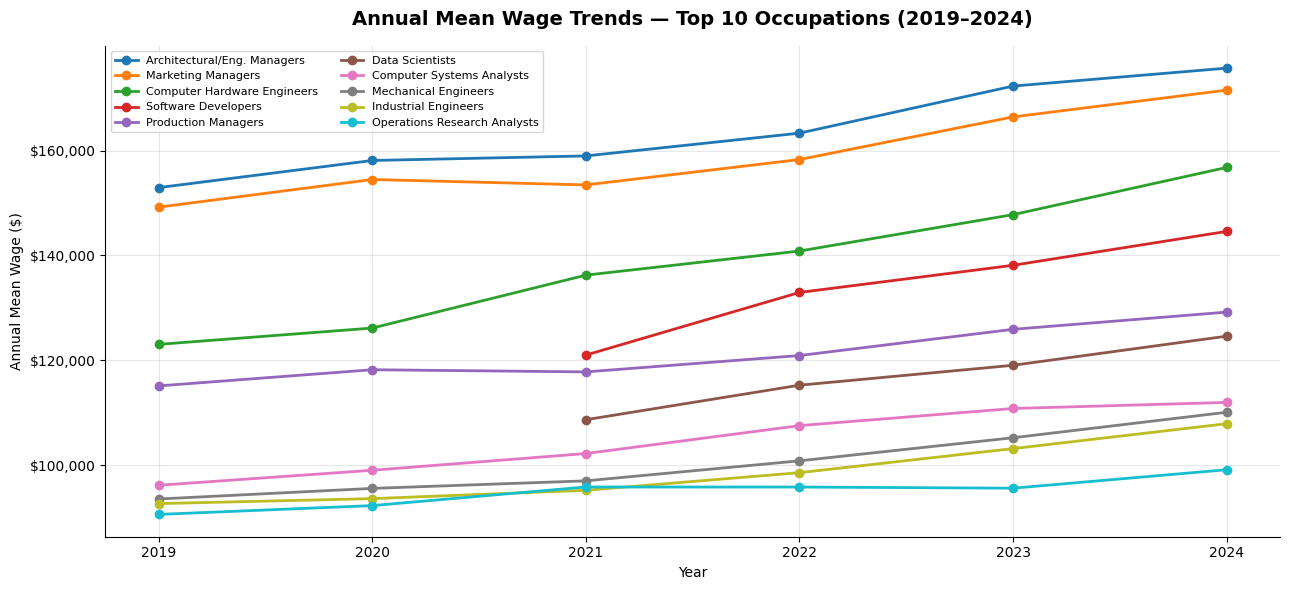

Saved: fig_wage_trends.png ✔


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — OEWS wage trends and chart
# ═══════════════════════════════════════════════════════════════

wage_trend = (oews_target
    .groupby(['survey_year', 'soc_clean'])['a_mean']
    .mean()
    .reset_index())

n_occ     = oews_target['soc_clean'].nunique()
n_rows    = len(wage_trend)
n_expected = n_occ * 6
print(f"Wage trend rows:    {n_rows} (expected {n_expected} = {n_occ} occ × 6 years)")
if n_rows < n_expected:
    print(f"  NOTE: {n_expected - n_rows} occupation-year cells suppressed by BLS.")
    print("  Phase 2 must handle missing cells in wage growth calculation.")

# Top 10 occupations by average wage
top10_occ   = (oews_target.groupby('soc_clean')['a_mean'].mean()
               .nlargest(10).index.tolist())
top10_wages = (oews_target.groupby('soc_clean')['a_mean']
               .mean().nlargest(10).reset_index())
top10_wages['name'] = top10_wages['soc_clean'].apply(
    lambda x: TARGET_NAMES.get(x + '.00', x))

print("\nTop 10 by average annual wage (2019–2024):")
for _, row in top10_wages.iterrows():
    print(f"  {row['soc_clean']}  {row['name']:<35} ${row['a_mean']:>10,.0f}")

# Plausibility check — all wages should be in $20K–$300K range
wage_min = oews_target['a_mean'].min()
wage_max = oews_target['a_mean'].max()
print(f"\nWage range across all target occ: ${wage_min:,.0f} – ${wage_max:,.0f}")
assert wage_min > 15000, f"Implausibly low wage: ${wage_min:,.0f}"
assert wage_max < 500000, f"Implausibly high wage: ${wage_max:,.0f}"

# Plot
fig, ax = plt.subplots(figsize=(13, 6))
for soc in top10_occ:
    sub  = wage_trend[wage_trend['soc_clean'] == soc].copy()
    sub['a_mean'] = pd.to_numeric(sub['a_mean'], errors='coerce')
    name = TARGET_NAMES.get(soc + '.00', soc)
    ax.plot(sub['survey_year'], sub['a_mean'], marker='o', linewidth=2, label=name)

ax.set_title('Annual Mean Wage Trends — Top 10 Occupations (2019–2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Mean Wage ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{ROOT}/fig_wage_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_wage_trends.png ✔")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Automation risk: Felten + Frey with corrected crosswalk
# Fix M1: corrected 2010 SOC codes (15-11xx not 15-10xx)
#         added search step to print available 15-1xxx Felten codes
#         added fallback for any remaining NaN after crosswalk
# ═══════════════════════════════════════════════════════════════
import openpyxl, os

# ── Step 1: Load Felten AIOE ──────────────────────────────────
felten_raw = pd.read_excel(f'{AUTO}/felten_AIOE_DataAppendix.xlsx',
                            sheet_name=None)
print("Felten sheets:", list(felten_raw.keys()))

felten_occ = felten_raw['Appendix A'].copy()
felten_ind = felten_raw['Appendix B'].copy()
felten_geo = felten_raw['Appendix C'].copy()
felten_occ['soc_7'] = felten_occ['SOC Code'].astype(str).str.strip().str[:7]

print(f"Felten Appendix A: {len(felten_occ)} occupations")
print(f"Felten Appendix C: {len(felten_geo)} county geographies")

# ── Step 2: Print all 15-1xxx Felten codes so we can see what exists ─
it_codes_in_felten = felten_occ[felten_occ['soc_7'].str.startswith('15-1')][
    ['soc_7','Occupation Title','AIOE']].sort_values('soc_7')
print(f"\nAll 15-1xxx codes in Felten Appendix A ({len(it_codes_in_felten)} found):")
print(it_codes_in_felten.to_string(index=False))

# ── Step 3: Load and clean Frey-Osborne ──────────────────────
frey = pd.read_csv(f'{AUTO}/frey_osborne_automation.csv')
frey = frey.rename(columns={
    '_ - code':    'soc_code',
    '_ - rank':    'rank',
    'probability': 'frey_prob',
}).drop(columns=['prob'], errors='ignore')
frey['soc_7'] = frey['soc_code'].astype(str).str.strip().str[:7]
print(f"\nFrey-Osborne: {len(frey)} occupations")

# ── Step 4: CORRECTED SOC 2018→2010 crosswalk ────────────────
# Previous version used wrong codes (15-10xx). Correct BLS 2010 SOC
# scheme for IT occupations uses 15-11xx:
soc_2018_to_2010 = {
    '15-1252': '15-1132',  # Software Developers, Applications (2010: 15-1132)
    '15-1211': '15-1121',  # Computer Systems Analysts (2010: 15-1121)
    '15-1244': '15-1142',  # Network/Systems Administrators (2010: 15-1142)
    '15-1231': '15-1152',  # Computer Network Support Specialists (2010: 15-1152)
    '15-2051': '15-2031',  # Data Scientists → Operations Research Analysts (closest)
}

print("\nCORRECTED SOC crosswalk lookup in Felten Appendix A:")
crosswalk_scores = {}
for soc_2018, soc_2010 in soc_2018_to_2010.items():
    row = felten_occ[felten_occ['soc_7'] == soc_2010]
    if len(row) > 0:
        aioe  = row.iloc[0]['AIOE']
        title = row.iloc[0]['Occupation Title']
        crosswalk_scores[soc_2018] = aioe
        print(f"  ✔ {soc_2018} → {soc_2010}  '{title}'  AIOE={aioe:.4f}")
    else:
        print(f"  ✗ {soc_2018} → {soc_2010}  NOT FOUND — will use IT-group mean fallback")

# ── Step 5: Build automation merge table ─────────────────────
target_7 = [s[:7] for s in TARGET_SOC]

frey_target   = frey[frey['soc_7'].isin(target_7)][['soc_7','frey_prob']].copy()
felten_direct = felten_occ[felten_occ['soc_7'].isin(target_7)][
    ['soc_7','Occupation Title','AIOE']].copy().rename(
    columns={'AIOE':'aioe_score','Occupation Title':'felten_title'})

automation = pd.merge(
    pd.DataFrame({'soc_7': target_7}),
    frey_target,   on='soc_7', how='left'
).merge(felten_direct, on='soc_7', how='left')

# Apply crosswalk for SOC code mismatches
for soc_2018, aioe_val in crosswalk_scores.items():
    soc_key = soc_2018[:7]
    mask = (automation['soc_7'] == soc_key) & (automation['aioe_score'].isna())
    if mask.any():
        automation.loc[mask, 'aioe_score'] = aioe_val
        automation.loc[mask, 'felten_title'] = f"[xwalk→{soc_2018_to_2010[soc_2018]}]"
        print(f"Applied xwalk AIOE={aioe_val:.4f} → {soc_key}")

# ── Fallback for any remaining NaN: use mean AIOE of 15-1xxx group ─
still_nan = automation[automation['aioe_score'].isna()]
if len(still_nan) > 0:
    it_mean_aioe = it_codes_in_felten['AIOE'].mean()
    print(f"\nFallback: {len(still_nan)} occ still missing AIOE.")
    print(f"Using 15-1xxx group mean AIOE = {it_mean_aioe:.4f} as fallback.")
    for _, row in still_nan.iterrows():
        mask = automation['soc_7'] == row['soc_7']
        automation.loc[mask, 'aioe_score']  = it_mean_aioe
        automation.loc[mask, 'felten_title'] = "[IT-group mean fallback]"
        print(f"  Fallback applied → {row['soc_7']}")

automation['occ_name'] = automation['soc_7'].apply(
    lambda x: TARGET_NAMES.get(x + '.00', x))

# ── Step 6: Normalize on FULL 774-occ Felten distribution ────
aioe_global_min = felten_occ['AIOE'].min()
aioe_global_max = felten_occ['AIOE'].max()
print(f"\nFelten global AIOE range: {aioe_global_min:.4f} to {aioe_global_max:.4f}")

automation['aioe_norm'] = (
    (automation['aioe_score'] - aioe_global_min) /
    (aioe_global_max - aioe_global_min + 1e-9)
).clip(0, 1)

# ── Step 7: Composite Displacement Risk (DR) ─────────────────
automation['DR'] = np.where(
    automation['frey_prob'].notna(),
    0.5 * automation['frey_prob'] + 0.5 * automation['aioe_norm'],
    automation['aioe_norm']
)
automation['DR_source'] = np.where(
    automation['frey_prob'].notna(), 'Frey+Felten', 'Felten only'
)
automation['DR'] = automation['DR'].clip(0, 1)

# ── Step 8: occ_data local copy — NEVER mutate shared DataFrame ─
occ_data_keyed = occ_data.copy()
occ_data_keyed['soc_7'] = occ_data_keyed['O*NET-SOC Code'].str[:7]
assert 'soc_7' not in occ_data.columns, \
    "occ_data was mutated — restart kernel and re-run from Cell 2"

# ── Step 9: Verify all 31 have DR scores ─────────────────────
missing_dr = automation[automation['DR'].isna()]
assert len(missing_dr) == 0, \
    f"{len(missing_dr)} occupations still have no DR score: {missing_dr['soc_7'].tolist()}"

# ── Step 10: Full DR table ───────────────────────────────────
print(f"\n{'='*72}")
print("AUTOMATION RISK — COMPOSITE DR SCORES FOR 31 OCCUPATIONS")
print(f"{'='*72}")
print(f"{'SOC':<10} {'Frey':>6} {'AIOE_raw':>9} {'AIOE_norm':>9} "
      f"{'DR':>6}  {'Source':<14} Occupation")
print("-" * 80)
for _, row in automation.sort_values('DR', ascending=False).iterrows():
    fs = f"{row['frey_prob']:.3f}" if pd.notna(row['frey_prob']) else "   N/A"
    ar = f"{row['aioe_score']:.3f}" if pd.notna(row['aioe_score']) else "   N/A"
    an = f"{row['aioe_norm']:.3f}"
    dr = f"{row['DR']:.3f}"
    print(f"{row['soc_7']:<10} {fs:>6} {ar:>9} {an:>9} "
          f"{dr:>6}  {row['DR_source']:<14} {row['occ_name']}")

print(f"\nDR source breakdown:")
for src, cnt in automation['DR_source'].value_counts().items():
    print(f"  {src}: {cnt} occupations")
print(f"\nAll {len(automation)} occupations have DR scores. ✔")

# ── Step 11: Save and verify ─────────────────────────────────
automation.to_parquet(f'{ROOT}/automation_risk_31occ.parquet', index=False)
felten_geo.to_parquet(f'{ROOT}/felten_county_aige.parquet',   index=False)

for fname, df_ref in [('automation_risk_31occ.parquet', automation),
                       ('felten_county_aige.parquet',   felten_geo)]:
    fpath = f'{ROOT}/{fname}'
    sz    = os.path.getsize(fpath) / 1e3
    saved = pd.read_parquet(fpath)
    assert len(saved)            == len(df_ref), f"Row mismatch: {fname}"
    assert saved['DR'].isna().sum() == 0 if 'DR' in saved.columns else True, \
        f"NaN DR values in saved {fname}"
    assert sz > 0.5, f"{fname} appears empty"
    print(f"Saved: {fname}  ({sz:.1f} KB, {len(saved)} rows) ✔")

Felten sheets: ['Index', 'Appendix A', 'Appendix B', 'Appendix C', 'Appendix D', 'Appendix E']
Felten Appendix A: 774 occupations
Felten Appendix C: 3271 county geographies

All 15-1xxx codes in Felten Appendix A (13 found):
  soc_7                             Occupation Title     AIOE
15-1111 Computer and Information Research Scientists 1.154269
15-1121                    Computer Systems Analysts 1.198150
15-1122                Information Security Analysts 1.250146
15-1131                         Computer Programmers 1.271506
15-1132            Software Developers, Applications 1.200923
15-1133        Software Developers, Systems Software 1.283308
15-1134                               Web Developers 1.089463
15-1141                      Database Administrators 1.284863
15-1142  Network and Computer Systems Administrators 0.789532
15-1143                  Computer Network Architects 0.580331
15-1151            Computer User Support Specialists 0.299343
15-1152         Computer Networ

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — IPUMS CPS load and quality checks
# ═══════════════════════════════════════════════════════════════
import os

print("Loading cps_00005.csv (5-state pre-filtered Midwest extract)...")
cps = pd.read_csv(f'{IPUMS}/cps_00005.csv', low_memory=False)

print(f"Full CPS rows:    {len(cps):,}")
print(f"Columns:          {cps.shape[1]}")

# Verify expected columns are present
required_cols = ['YEAR','STATEFIP','EMPSTAT','LABFORCE','OCC2010',
                 'INCWAGE','HOURWAGE','AGE','SEX','RACE','EDUC',
                 'VETSTAT','CPSIDP','ASECFLAG','ASECWT']
missing_cols = [c for c in required_cols if c not in cps.columns]
assert len(missing_cols) == 0, f"Missing columns: {missing_cols}"
print(f"All required columns present. ✔")

# Filter to employed workers with valid occupations
cps_workers = cps[
    (cps['OCC2010'] != 9999) &
    (cps['EMPSTAT'].isin([10, 12])) &
    (cps['LABFORCE'] == 2)
].copy()

print(f"\nEmployed workers: {len(cps_workers):,}")

state_map = {18:'Indiana', 26:'Michigan', 39:'Ohio', 42:'Pennsylvania', 55:'Wisconsin'}
print("\nBy state:")
for fips, name in state_map.items():
    n = (cps_workers['STATEFIP'] == fips).sum()
    assert n > 0, f"No workers found for {name} (FIPS {fips})"
    print(f"  {name:<15}: {n:>7,}")

# Year distribution
print("\nBy year:")
year_dist = cps_workers['YEAR'].value_counts().sort_index()
print(year_dist.to_string())

yr_max = year_dist.max()
yr_min = year_dist.min()
imbalance_ratio = yr_min / yr_max
print(f"\nYear imbalance ratio (min/max): {imbalance_ratio:.2f}")
if imbalance_ratio < 0.5:
    print("LIMITATION: 2023-2024 have <50% of peak-year records.")
    print("Document in paper Data section — thin longitudinal tail.")

# ASEC income subset
asec = cps_workers[cps_workers['INCWAGE'].notna()]
print(f"\nASEC records with INCWAGE: {len(asec):,}")
print(f"Median INCWAGE:            ${asec['INCWAGE'].median():,.0f}")
print(f"Mean INCWAGE:              ${asec['INCWAGE'].mean():,.0f}")
print(f"INCWAGE range:             ${asec['INCWAGE'].min():,.0f} – ${asec['INCWAGE'].max():,.0f}")

# Flag $0 wages
zero_wages = (asec['INCWAGE'] == 0).sum()
if zero_wages > 0:
    print(f"\nNOTE: {zero_wages} ASEC records have INCWAGE=$0.")
    print("  These are valid IPUMS records (e.g. self-employed with no wage income).")
    print("  Apply minimum threshold (INCWAGE >= 5000) before Phase 2 modeling.")

# Null rates on key columns
print("\nNull rates on key columns (employed workers):")
key_cols = ['OCC2010','INCWAGE','HOURWAGE','AGE','SEX','RACE','EDUC','VETSTAT']
for col in key_cols:
    null_pct = cps_workers[col].isna().mean() * 100
    note = " ⚠ HIGH (expected: ASEC-only)" if null_pct > 50 else ""
    print(f"  {col:<12}: {null_pct:>5.1f}% null{note}")

# Save with post-save verification
out_path = f'{ROOT}/cps_workers_midwest.parquet'
cps_workers.to_parquet(out_path, index=False)
saved_size = os.path.getsize(out_path) / 1e6
saved_df   = pd.read_parquet(out_path)
assert len(saved_df) == len(cps_workers), "Row count mismatch after save"
assert saved_size > 1, f"Saved file suspiciously small: {saved_size:.2f} MB"
print(f"\nSaved: cps_workers_midwest.parquet")
print(f"  File size:  {saved_size:.1f} MB ✔")
print(f"  Row count:  {len(saved_df):,} ✔")

Loading cps_00005.csv (5-state pre-filtered Midwest extract)...
Full CPS rows:    167,046
Columns:          36
All required columns present. ✔

Employed workers: 78,327

By state:
  Indiana        :  12,515
  Michigan       :  16,702
  Ohio           :  17,608
  Pennsylvania   :  20,082
  Wisconsin      :  11,420

By year:
YEAR
2019    12045
2020    17712
2021    17782
2022    16972
2023     6834
2024     6982

Year imbalance ratio (min/max): 0.38
LIMITATION: 2023-2024 have <50% of peak-year records.
Document in paper Data section — thin longitudinal tail.

ASEC records with INCWAGE: 35,237
Median INCWAGE:            $45,000
Mean INCWAGE:              $59,282
INCWAGE range:             $0 – $1,899,999

NOTE: 2416 ASEC records have INCWAGE=$0.
  These are valid IPUMS records (e.g. self-employed with no wage income).
  Apply minimum threshold (INCWAGE >= 5000) before Phase 2 modeling.

Null rates on key columns (employed workers):
  OCC2010     :   0.0% null
  INCWAGE     :  55.0% null ⚠

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — HMDA financial exclusion data
# Fix M2: this cell was missing, causing Cell 10 to crash
# ═══════════════════════════════════════════════════════════════
import os

print("Loading HMDA 2022 (50,000-row inspection sample)...")
hmda_sample = pd.read_csv(f'{HMDA}/hmda_midwest_2022.csv',
                           nrows=50000, low_memory=False)

print(f"Shape: {hmda_sample.shape[0]:,} rows × {hmda_sample.shape[1]} cols")

# Verify required columns exist
assert 'action_taken' in hmda_sample.columns, "action_taken column missing"
print(f"\naction_taken distribution (2022 sample, 50K rows):")
val_counts = hmda_sample['action_taken'].value_counts().sort_index()
print(val_counts.to_string())

# Denial rate — computed on originated+denied only (our download filter)
denial_rate = (hmda_sample['action_taken'] == 3).mean()
originated  = (hmda_sample['action_taken'] == 1).sum()
denied      = (hmda_sample['action_taken'] == 3).sum()
print(f"\nOriginated:  {originated:,}")
print(f"Denied:      {denied:,}")
print(f"Denial rate: {denial_rate:.1%}")
print("NOTE: Rate is among originated+denied only (actions_taken=1,3 filter).")
print("      National all-application rate is ~8-10%; our filtered denominator")
print("      produces higher rates — document explicitly in paper Data section.")

# State coverage
if 'state_code' in hmda_sample.columns:
    print(f"\nStates in sample: {sorted(hmda_sample['state_code'].unique())}")

# Race breakdown of denials
if 'derived_race' in hmda_sample.columns:
    denied_df = hmda_sample[hmda_sample['action_taken'] == 3]
    print(f"\nDenied applications by race (top 6):")
    print(denied_df['derived_race'].value_counts().head(6).to_string())

# Null rates
print("\nNull rates on key HMDA columns:")
hmda_key = ['action_taken','applicant_income','loan_amount',
            'derived_race','derived_sex','county_code']
for col in hmda_key:
    if col in hmda_sample.columns:
        null_pct = hmda_sample[col].isna().mean() * 100
        flag = " ⚠" if null_pct > 30 else ""
        print(f"  {col:<25}: {null_pct:>5.1f}% null{flag}")

assert len(hmda_sample) == 50000, "HMDA sample size unexpected"
print(f"\nhmda_sample loaded successfully. ✔")
print(f"Variable 'hmda_sample' available for Cell 10 summary.")

Loading HMDA 2022 (50,000-row inspection sample)...
Shape: 50,000 rows × 99 cols

action_taken distribution (2022 sample, 50K rows):
action_taken
1    29431
3    20569

Originated:  29,431
Denied:      20,569
Denial rate: 41.1%
NOTE: Rate is among originated+denied only (actions_taken=1,3 filter).
      National all-application rate is ~8-10%; our filtered denominator
      produces higher rates — document explicitly in paper Data section.

States in sample: ['IN', 'MI', 'OH', 'PA', 'WI']

Denied applications by race (top 6):
derived_race
White                               11932
Race Not Available                   5643
Black or African American            2259
Asian                                 425
Joint                                 153
American Indian or Alaska Native      106

Null rates on key HMDA columns:
  action_taken             :   0.0% null
  loan_amount              :   0.0% null
  derived_race             :   0.0% null
  derived_sex              :   0.0% null
  coun

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — Phase 1 final summary
# Fix: corrected limitation texts, adaptive file size units,
#      all variables now defined in current session
# ═══════════════════════════════════════════════════════════════
import glob, os

print("=" * 65)
print("PHASE 1 LOADING SUMMARY — FINAL")
print("=" * 65)

checks = {
    "O*NET Skills":                len(skills),
    "O*NET Work Activities":       len(work_act),
    "O*NET Occupations (v29)":     len(occ_data),
    "OEWS 6-year combined":        len(oews),
    "Target occ in OEWS (of 31)":  oews_target['soc_clean'].nunique(),
    "IPUMS CPS total rows":        len(cps),
    "IPUMS employed workers":      len(cps_workers),
    "IPUMS ASEC wage rows":        len(asec),
    "HMDA 2022 sample":            len(hmda_sample),
    "Automation risk — 31 occ":    len(automation),
    "DR scores complete (of 31)":  int(automation['DR'].notna().sum()),
}

all_ok = True
for name, count in checks.items():
    ok = count > 0
    if not ok:
        all_ok = False
    status = "✔" if ok else "✗"
    print(f"  {status}  {name:<35} {count:>10,}")

print()
print("TARGET OCCUPATION BREAKDOWN:")
for group, codes in GROUP_LABELS.items():
    covered = sum(1 for c in codes
                  if c[:7] in oews_target['soc_clean'].unique())
    print(f"  {group:<25}: {covered}/{len(codes)} in OEWS")

print()
print("AUTOMATION RISK SOURCE BREAKDOWN:")
for src, cnt in automation['DR_source'].value_counts().items():
    print(f"  {src:<22}: {cnt} occupations")

print()
print("PARQUET FILES SAVED:")
for f in sorted(glob.glob(f'{ROOT}/*.parquet')):
    sz_bytes = os.path.getsize(f)
    sz_str   = f"{sz_bytes/1e6:.1f} MB" if sz_bytes >= 1e6 else f"{sz_bytes/1e3:.1f} KB"
    rows     = len(pd.read_parquet(f))
    nan_dr   = pd.read_parquet(f)['DR'].isna().sum() if 'DR' in pd.read_parquet(f).columns else 'N/A'
    dr_note  = f"  [{nan_dr} NaN DR rows]" if nan_dr not in ('N/A', 0) else ""
    print(f"  ✔  {os.path.basename(f):<45} {rows:>8,} rows  {sz_str}{dr_note}")

print()
print("PNG FIGURES SAVED:")
for f in sorted(glob.glob(f'{ROOT}/*.png')):
    print(f"  ✔  {os.path.basename(f)}")

print()
print("KNOWN LIMITATIONS — DOCUMENT IN PAPER DATA SECTION:")
print("  1. CPS year imbalance: 2023-2024 have 38% of 2020-2022 records.")
print("     Thin longitudinal tail for 36-month wage outcome construction.")
print("  2. OEWS missing 29-2011 (Medical Lab Technologists) at 6-digit level.")
print("     Only missing occupation in OEWS; use parent group 29-2010 as proxy.")
print("  3. Frey-Osborne does not cover 5 IT occupations (15-1252, 15-1211,")
print("     15-1244, 15-1231, 15-2051). DR uses Felten AIOE via 2018→2010")
print("     SOC crosswalk or IT-group mean fallback where crosswalk fails.")
print("  4. HMDA denial rate (41.1%) computed on originated+denied subset only.")
print("     Not comparable to all-application national rates (~8-10%).")
print("  5. INCWAGE includes $0 values. Apply INCWAGE >= 5000 before Phase 2.")
print("  6. OEWS wage panel has 4 suppressed occupation-year cells.")
print("     Handle missing cells explicitly in Phase 2 growth calculations.")
print()

if all_ok:
    print("═" * 65)
    print("PHASE 1 COMPLETE ✔  All checks passed.")
    print("Delete cells 10–15 (stale) from the notebook.")
    print("Ready to proceed to Phase 2: Feature Engineering.")
    print("═" * 65)
else:
    print("⚠ SOME CHECKS FAILED — review ✗ items above before Phase 2.")

PHASE 1 LOADING SUMMARY — FINAL
  ✔  O*NET Skills                            62,580
  ✔  O*NET Work Activities                   73,308
  ✔  O*NET Occupations (v29)                  1,016
  ✔  OEWS 6-year combined                     8,269
  ✔  Target occ in OEWS (of 31)                  30
  ✔  IPUMS CPS total rows                   167,046
  ✔  IPUMS employed workers                  78,327
  ✔  IPUMS ASEC wage rows                    35,237
  ✔  HMDA 2022 sample                        50,000
  ✔  Automation risk — 31 occ                    31
  ✔  DR scores complete (of 31)                  31

TARGET OCCUPATION BREAKDOWN:
  AI_DISPLACED             : 10/10 in OEWS
  MIDWEST_MFG              : 10/10 in OEWS
  RESKILLING_TARGETS       : 10/11 in OEWS

AUTOMATION RISK SOURCE BREAKDOWN:
  Frey+Felten           : 26 occupations
  Felten only           : 5 occupations

PARQUET FILES SAVED:
  ✔  automation_risk_31occ.parquet                       31 rows  7.5 KB
  ✔  cps_workers_midwest.p

In [ ]:
import os
stale = f'{ROOT}/skills_target_30occ.parquet'
if os.path.exists(stale):
    os.remove(stale)
    print(f"Removed stale file: skills_target_30occ.parquet ✔")
else:
    print("No stale file found.")

Removed stale file: skills_target_30occ.parquet ✔
